# Importing Libraries

In [139]:
!pip install --upgrade imutils

In [140]:
from keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from keras.layers.convolutional import Conv2D, MaxPooling2D
from keras.layers.core import Activation, Flatten, Flatten, Dropout, Dense
from keras import backend as K
from tensorflow.keras.utils import img_to_array, load_img
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from keras import preprocessing
import random

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
from tqdm.notebook import tqdm
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
import torchmetrics
from torchmetrics import Metric
import torchvision
from torchvision import models
import cv2 as op

plt.style.use('seaborn')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

np.__version__, device

/tmp/ipykernel_32/3435668452.py:18: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


('1.23.5', 'cuda')

In [142]:
class SmallerVGGNet:
    @staticmethod
    def build(width, height, depth, classes, finalAct="softmax"):
        model = Sequential()
        inputShape = (height, width, depth)

        # CONV => RELU => POOL
        model.add(Conv2D(32, (3, 3), padding="same",
                         input_shape=inputShape))
        model.add(Activation("relu"))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(3, 3)))
        model.add(Dropout(0.25))

        # CONV => RELU => CONV => RELU => POOL
        model.add(Conv2D(64, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(BatchNormalization())
        model.add(Conv2D(64, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))

        # CONV => RELU => CONV => RELU => POOL
        model.add(Conv2D(128, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(BatchNormalization())
        model.add(Conv2D(128, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))

        # FC => RELU
        model.add(Flatten())
        model.add(Dense(1024))
        model.add(Activation("relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.5))

        # Output
        model.add(Dense(classes))
        model.add(Activation(finalAct))

        return model

# Loading the data

In [143]:
TRAIN_PATH = '/kaggle/input/fresh-and-stale-classification/dataset/Train'
TEST_PATH = '/kaggle/input/fresh-and-stale-classification/dataset/Test'

def load_data(PATH):
    filenames, fruit, fresh = [], [], []
    
    for file in tqdm(os.listdir(PATH)):
        for img in os.listdir(os.path.join(PATH, file)):
            fresh.append(0 if file[0] == 'f' else 1)
            fruit.append(file[5:] if file[0] == 'f' else file[6: ])
            filenames.append(os.path.join(PATH, file, img))
            
    df = pd.DataFrame({
        'filename' : filenames,
        'fruit' : fruit,
        'fresh' : fresh
    })
    
    return df

df_train = load_data(TRAIN_PATH)
df_test = load_data(TEST_PATH)

df_train.shape, df_test.shape
    

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

((23619, 3), (6738, 3))

## Data Preprocessing

In [144]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23619 entries, 0 to 23618
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  23619 non-null  object
 1   fruit     23619 non-null  object
 2   fresh     23619 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 553.7+ KB


In [145]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  6738 non-null   object
 1   fruit     6738 non-null   object
 2   fresh     6738 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 158.0+ KB


In [146]:
print(df_train['fruit'].value_counts())

apples         5672
banana         5400
tomato         3683
oranges        3061
capsicum       1891
potato         1338
okra            973
cucumber        917
bittergroud     684
Name: fruit, dtype: int64


In [147]:
print(df_test['fruit'].value_counts())

banana      1792
apples      1779
oranges      791
patato       640
tamto        608
okra         594
cucumber     534
Name: fruit, dtype: int64


In [148]:
# threshold_counts = {'apples': 2000, 'banana': 2000,
#                     'oranges': 2000, 'tomato': 2000}

# for fruit, threshold in threshold_counts.items():
#     fruit_indices = df[df['fruit'] == fruit].index
#     if len(fruit_indices) > threshold:
#         rows_to_drop = fruit_indices[:len(fruit_indices) - threshold]
#         df = df.drop(rows_to_drop)

# print(df['fruit'].value_counts())

In [149]:
# apples_indices = df[df['fruit'] == 'apples'].index
# banana_indices = df[df['fruit'] == 'banana'].index
# oranges_indices = df[df['fruit'] == 'oranges'].index
# tomato_indices = df[df['fruit'] == 'tomato'].index

# if len(apples_indices) > 2000:
#     rows_to_drop = apples_indices[:len(apples_indices) - 2000]
#     df = df.drop(rows_to_drop)

# if len(banana_indices) > 2000:
#     rows_to_drop = banana_indices[:len(banana_indices) - 2000]
#     df = df.drop(rows_to_drop)
    
# if len(oranges_indices) > 2000:
#     rows_to_drop = oranges_indices[:len(oranges_indices) - 2000]
#     df = df.drop(rows_to_drop)
    
# if len(tomato_indices) > 2000:
#     rows_to_drop = tomato_indices[:len(tomato_indices) - 2000]
#     df = df.drop(rows_to_drop)

# print(df['fruit'].value_counts())

<Axes: xlabel='fruit', ylabel='count'>

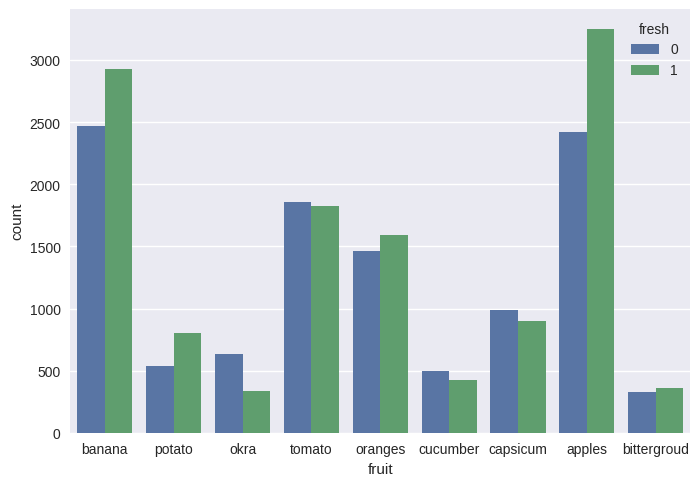

In [150]:
sea.countplot(x = 'fruit', data = df_train, hue = 'fresh')

<Axes: xlabel='fruit', ylabel='count'>

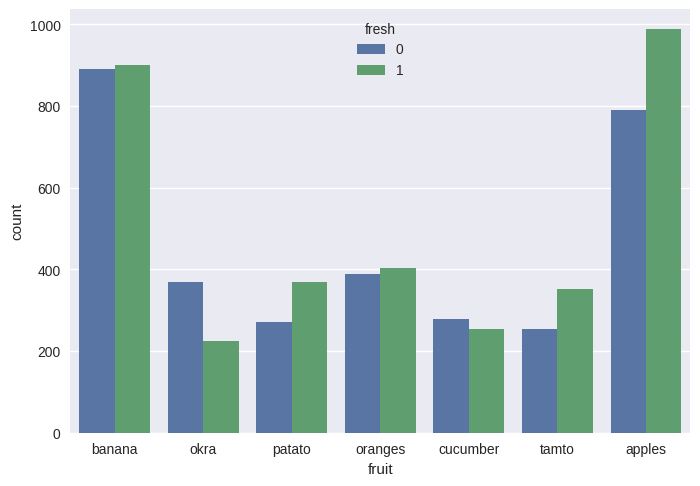

In [151]:
sea.countplot(x = 'fruit', data = df_test, hue = 'fresh')

## New balanced dataset

In [152]:
from sklearn.preprocessing import LabelEncoder
le_train = LabelEncoder()

df_train['fruit_label'] = le_train.fit_transform(df_train['fruit'])
df_train.shape

(23619, 4)

In [153]:
from sklearn.preprocessing import LabelEncoder
le_test = LabelEncoder()

df_test['fruit_label'] = le_test.fit_transform(df_test['fruit'])
df_test.shape

(6738, 4)

In [154]:
df_train.head()

,filename,fruit,fresh,fruit_label
0,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
1,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
2,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
3,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
4,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1


In [155]:
df_test.head()

,filename,fruit,fresh,fruit_label
0,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
1,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
2,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
3,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1
4,/kaggle/input/fresh-and-stale-classification/d...,banana,1,1


<Axes: xlabel='fruit', ylabel='count'>

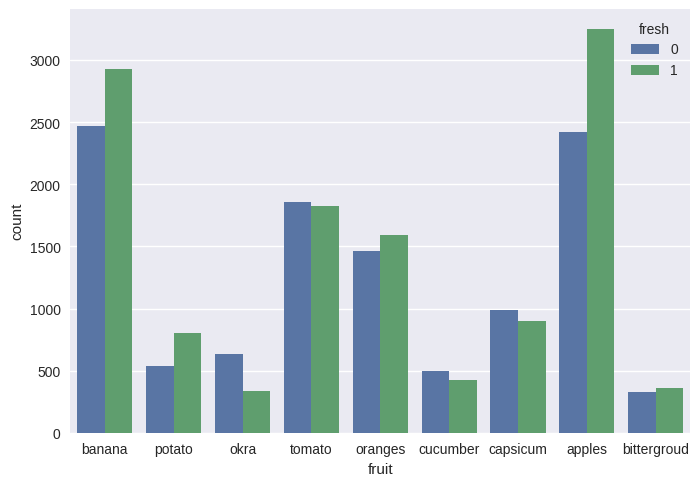

In [156]:
sea.countplot(x = 'fruit', data = df_train, hue = 'fresh')

<Axes: xlabel='fruit', ylabel='count'>

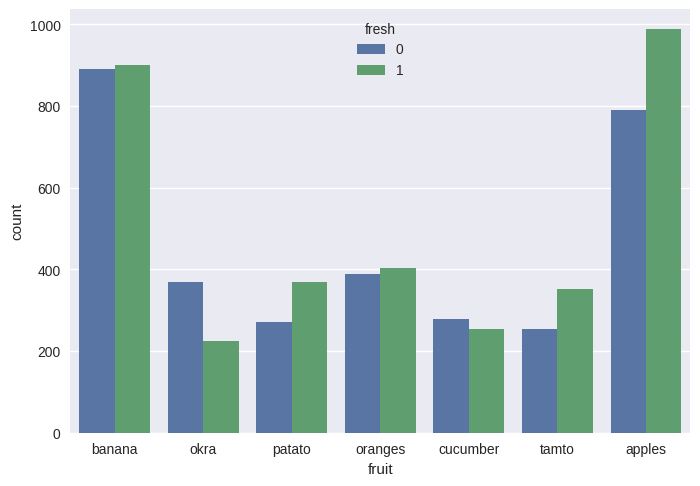

In [157]:
sea.countplot(x = 'fruit', data = df_test, hue = 'fresh')

In [158]:
df_train['fruit']

0        banana
1        banana
2        banana
3        banana
4        banana
          ...  
23614    potato
23615    potato
23616    potato
23617    potato
23618    potato
Name: fruit, Length: 23619, dtype: object

In [159]:
df_test['fruit']

0       banana
1       banana
2       banana
3       banana
4       banana
         ...  
6733     tamto
6734     tamto
6735     tamto
6736     tamto
6737     tamto
Name: fruit, Length: 6738, dtype: object

## Split train,test and validate

In [160]:
from sklearn.model_selection import train_test_split
df_train['fresh_fruit'] = df_train['fresh'].astype(str) + "_" + df_train['fruit_label'].astype(str)
df_train, df_val = train_test_split(df_train, test_size=0.2, stratify=df_train['fresh_fruit'])
df_train = df_train.drop('fresh_fruit', axis=1)
df_val=df_val.drop('fresh_fruit', axis=1)
df_train.shape, df_val.shape, df_test.shape

((18895, 4), (4724, 4), (6738, 4))

<Axes: xlabel='fruit_label', ylabel='count'>

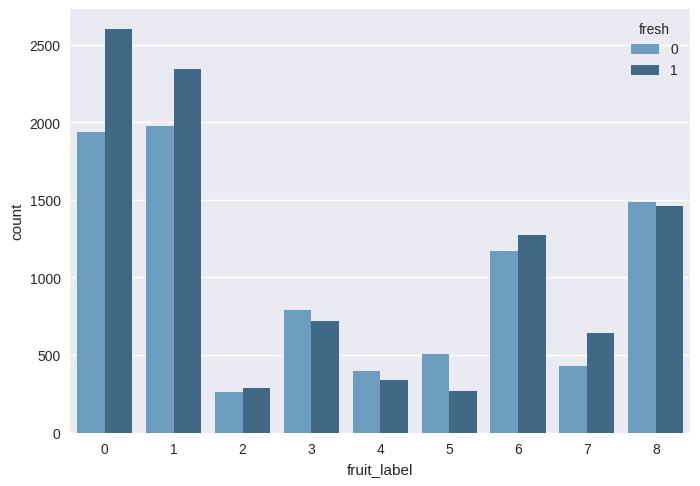

In [161]:
sea.countplot(x = 'fruit_label', data = df_train, hue = 'fresh', palette = 'Blues_d')

<Axes: xlabel='fruit', ylabel='count'>

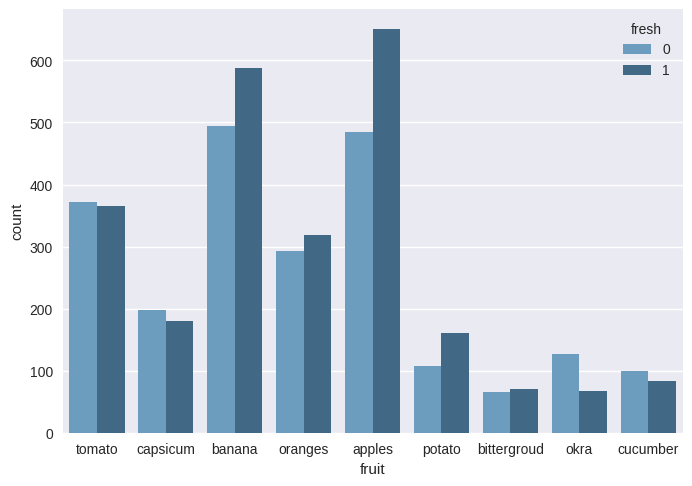

In [162]:
sea.countplot(x = 'fruit', data = df_val, hue = 'fresh', palette = 'Blues_d')

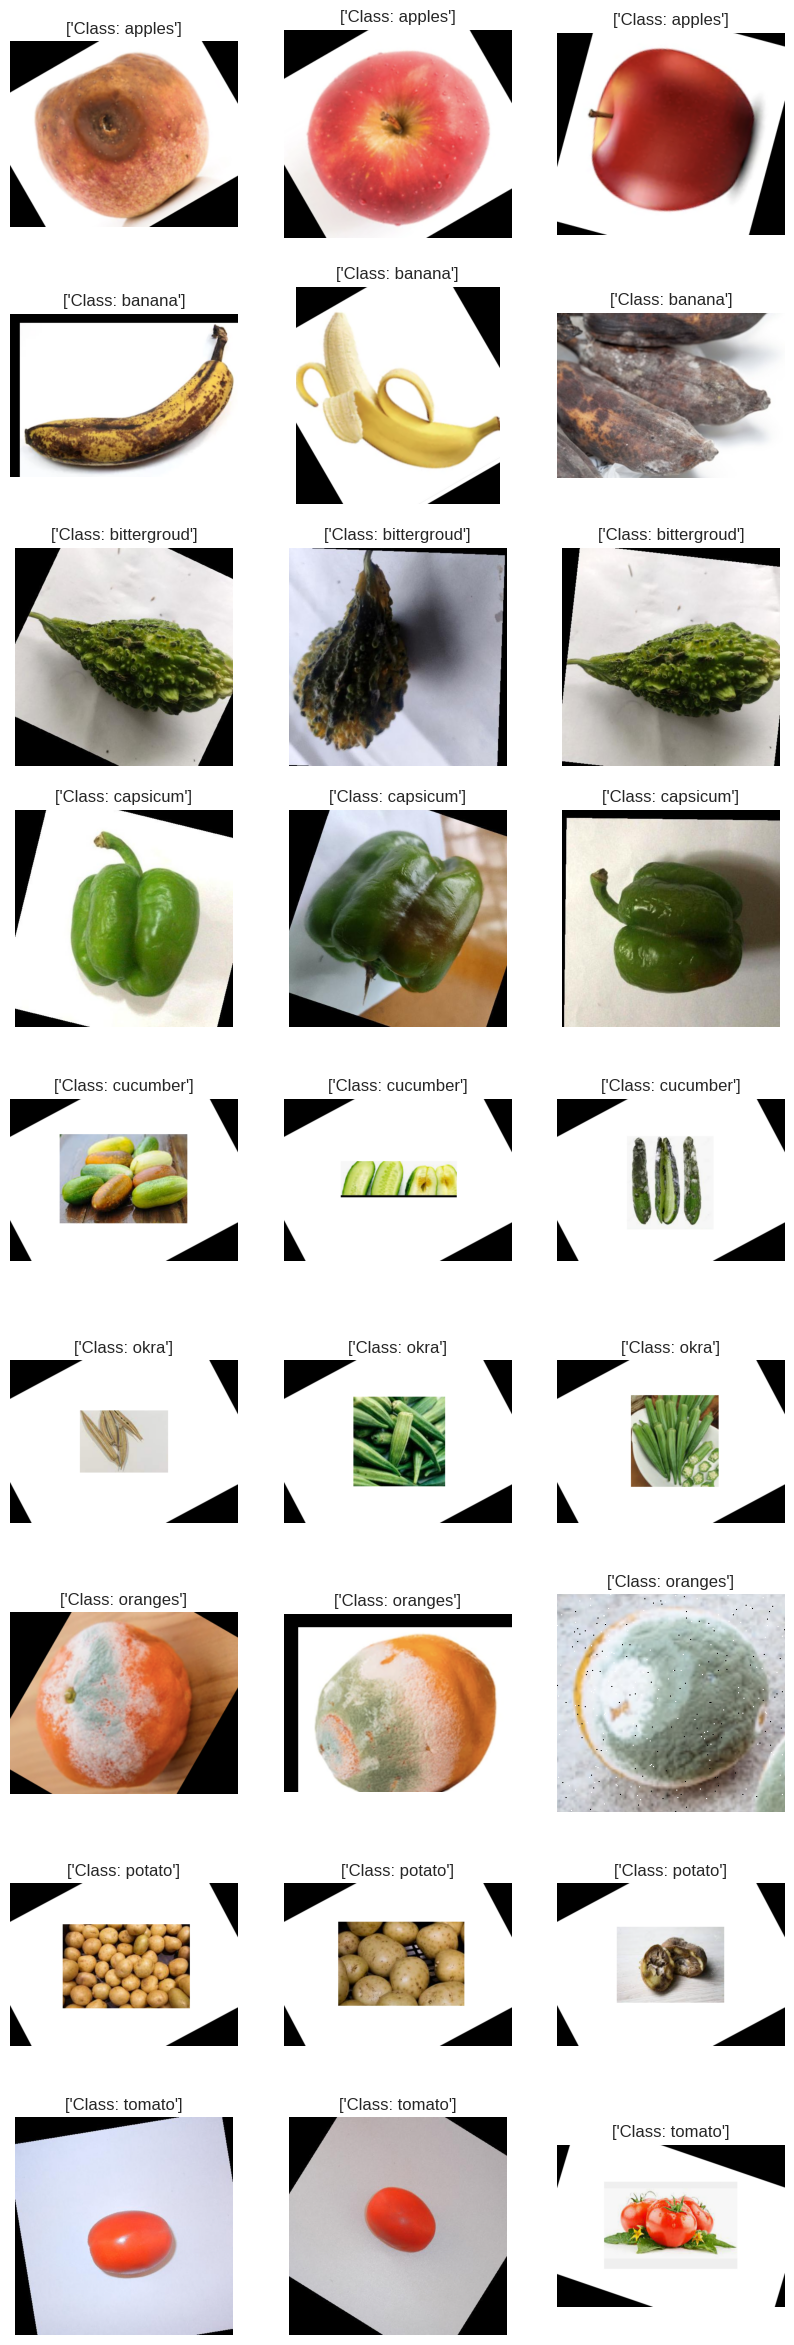

In [163]:
def load_image(path):
    img = plt.imread(path)
    return img

counter = 0

plt.figure(figsize = (10, 30))

for i in range(9):
    for path in df_train[df_train['fruit_label'] == i].sample(n = 3)['filename']:
        plt.subplot(9, 3, counter + 1)
        img = load_image(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title('Class:' + " " + le_train.inverse_transform([i]))
        counter += 1
        
plt.show()

# Building the dataset

In [164]:

def image_transform(img, p = 0.5, training = True):    
    if training:
        img = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p = p),
            transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
            transforms.RandomAdjustSharpness(3, p = p),
            transforms.Normalize(mean = 0, std = 1)
        ])(img)
    else:
        img = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
            transforms.Normalize(mean = 0, std = 1)
        ])(img)

    return img

class FruitDataset:
    def __init__(self, df, training):
        self.df = df
        self.n_samples = len(self.df)
        self.training = training
        
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        img = plt.imread(self.df.iloc[idx][0])[:, :, :3]
        fresh = torch.tensor(self.df.iloc[idx][2])
        fruit = torch.tensor(self.df.iloc[idx][3])

        img = image_transform(img, p = 0.5, training = self.training)
            
        return img, fruit, fresh
    

In [165]:
BATCH_SIZE = 64


train_dataset = FruitDataset(df_train, training = True)
val_dataset = FruitDataset(df_val, training = False)
test_dataset = FruitDataset(df_test, training = False)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE)


In [166]:
a, b, c = next(iter(train_loader))
print(a.shape, b.shape, c.shape)
del(a)
del(b)
del(c)

/opt/conda/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


torch.Size([64, 3, 224, 224]) torch.Size([64]) torch.Size([64])


# Train Model

In [167]:
          
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
from torchvision import models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

import math

class ModelVGG16(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = 0.7
        
        self.base = models.vgg16(pretrained=True)
        
        for param in list(self.base.parameters())[:-15]:
            param.requires_grad = False
                    
        self.base.classifier = nn.Sequential()  # Clear classifier
        self.base.fc = nn.Sequential()  # Remove fc layers
            
        # Custom blocks
        self.block1 = nn.Sequential(
            nn.Linear(512 * 7 * 7, 256),  # Adjust input size based on VGG16 output
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
        )
        
        self.block2 = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 9)
        )
        
        self.block3 = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 2)
        )

        # Optimizers
        self.optimizer1 = optim.Adam([
            {'params': self.base.parameters(), 'lr': 1e-5},
            {'params': self.block1.parameters(), 'lr': 3e-4}
        ])
        
        self.optimizer2 = optim.Adam(self.block2.parameters(), lr=3e-4)
        self.optimizer3 = optim.Adam(self.block3.parameters(), lr=3e-4)
        
        # Loss function
        self.loss_fxn = nn.CrossEntropyLoss()

        # Accuracy metrics
        self.fruit_accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=9)
        self.fresh_accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=2)
        
        self.TRAIN_BATCHES = math.ceil(len(train_dataset)/BATCH_SIZE)
        self.VAL_BATCHES = math.ceil(len(val_dataset)/BATCH_SIZE)

        self.history = {
            'train_loss': [], 'val_loss': [], 
            'train_acc_fruit': [], 'train_acc_fresh': [],
            'val_acc_fruit': [], 'val_acc_fresh': []
        }

    def forward(self, x):
        x = self.base.features(x)  # Use VGG16's convolutional layers
        x = torch.flatten(x, 1)    # Flatten the output
        x = self.block1(x)         # Pass through custom block1
        y1, y2 = self.block2(x), self.block3(x)  # Get predictions from block2 and block3
        
        return y1, y2

    
    def train_step(self, x, y1, y2):
        pred1, pred2 = self.forward(x)
        l1, l2 = self.loss_fxn(pred1, y1), self.loss_fxn(pred2, y2)

        self.optimizer2.zero_grad()
        l1.backward(retain_graph = True)
        self.optimizer2.step()
        
        self.optimizer3.zero_grad()
        l2.backward(retain_graph = True)
        self.optimizer3.step()
        
        
        loss = self.alpha * l1 + (1 - self.alpha) * l2
        self.optimizer1.zero_grad()
        loss.backward()
        self.optimizer1.step()
        
        fruit_acc = self.fruit_accuracy(torch.argmax(pred1, axis = 1), y1)
        fresh_acc = self.fresh_accuracy(torch.argmax(pred2, axis = 1), y2)
        
        return loss, fruit_acc, fresh_acc
    
    def val_step(self, x, y1, y2):
        with torch.no_grad():
            pred1, pred2 = self.forward(x)
            loss = self.alpha * self.loss_fxn(pred1, y1) + (1 - self.alpha) * self.loss_fxn(pred2, y2)

            fruit_acc = self.fruit_accuracy(torch.argmax(pred1, axis = 1), y1)
            fresh_acc = self.fresh_accuracy(torch.argmax(pred2, axis = 1), y2)
            return loss, fruit_acc, fresh_acc
        
    def update_history(self, train_loss, train_fruit, train_fresh, val_loss, val_fruit, val_fresh):
        self.history['train_loss'].append(train_loss)
        self.history['val_loss'].append(val_loss)
        self.history['train_acc_fresh'].append(train_fresh)
        self.history['train_acc_fruit'].append(train_fruit)
        self.history['val_acc_fresh'].append(val_fresh)
        self.history['val_acc_fruit'].append(val_fruit)
        
        
    def train(self, epochs = 5):
        
        for epoch in tqdm(range(epochs)):
            
            train_loss, train_fruit, train_fresh = 0, 0, 0
            val_loss, val_fruit, val_fresh = 0, 0, 0
            
            for X, y1, y2 in tqdm(train_loader):
                X, y1, y2 = [v.to(device) for v in (X, y1, y2)]
                loss, fruit_acc, fresh_acc = self.train_step(X, y1, y2)
                train_loss += loss.item()
                train_fruit += fruit_acc.item()
                train_fresh += fresh_acc.item()
                
            for X, y1, y2 in tqdm(val_loader):
                X, y1, y2 = [v.to(device) for v in (X, y1, y2)]
                loss, fruit_acc, fresh_acc = self.val_step(X, y1, y2)
                val_loss += loss.item()
                val_fruit += fruit_acc.item()
                val_fresh += fresh_acc.item()
                
            train_loss, train_fruit, train_fresh = [x/self.TRAIN_BATCHES for x in (train_loss, train_fruit, train_fresh)]
            val_loss, val_fruit, val_fresh = [x/self.VAL_BATCHES for x in (val_loss, val_fruit, val_fresh)]
            
            self.update_history( train_loss, train_fruit, train_fresh, val_loss, val_fruit, val_fresh)
            
            print("[Epoch: {}] Train: [loss: {:.3f}, fruit: {:.3f} fresh: {:.3f}] Val: [loss: {:.3f}, fruit: {:.3f} fresh: {:.3f}]".format(epoch, train_loss, train_fruit, train_fresh, 
                                                                                                                                          val_loss, val_fruit, val_fresh))
    def describe(self):
                print(self)
                print("\nModel structure:")
                print(self.base)
                print("\nBlock1:")
                print(self.block1)
                print("\nBlock2:")
                print(self.block2)
                print("\nBlock3:")
                print(self.block3)

In [168]:

model_vgg16 = ModelVGG16().to(device)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [169]:
from torchinfo import summary
print(summary(model_vgg16, input_size=(BATCH_SIZE, 3, 244, 244)))

0it [00:00, ?it/s]
100%|██████████| 296/296 [04:31<00:00,  1.09it/s]

100%|██████████| 1/1 [05:16<00:00, 316.90s/it]

[Epoch: 0] Train: [loss: 0.192, fruit: 0.939 fresh: 0.903] Val: [loss: 0.058, fruit: 0.989 fresh: 0.962]
Layer (type:depth-idx)                   Output Shape              Param #
ModelVGG16                               [64, 9]                   --
├─VGG: 1-1                               --                        --
│    └─Sequential: 2-1                   [64, 512, 7, 7]           --
│    │    └─Conv2d: 3-1                  [64, 64, 244, 244]        (1,792)
│    │    └─ReLU: 3-2                    [64, 64, 244, 244]        --
│    │    └─Conv2d: 3-3                  [64, 64, 244, 244]        (36,928)
│    │    └─ReLU: 3-4                    [64, 64, 244, 244]        --
│    │    └─MaxPool2d: 3-5               [64, 64, 122, 122]        --
│    │    └─Conv2d: 3-6                  [64, 128, 122, 122]       (73,856)
│    │    └─ReLU: 3-7                    [64, 128, 122, 122]       --
│    │    └─Conv2d: 3-8                  [64, 128, 122, 122]       (147,584)
│    │    └─ReLU: 3-9     

# Training the model

In [170]:

model_vgg16.train(epochs=5)

100%|██████████| 296/296 [04:20<00:00,  1.14it/s]

 20%|██        | 1/5 [05:03<20:14, 303.64s/it]

[Epoch: 0] Train: [loss: 0.042, fruit: 0.990 fresh: 0.972] Val: [loss: 0.042, fruit: 0.992 fresh: 0.965]



100%|██████████| 296/296 [04:13<00:00,  1.17it/s]

 40%|████      | 2/5 [09:59<14:57, 299.01s/it]

[Epoch: 1] Train: [loss: 0.025, fruit: 0.995 fresh: 0.982] Val: [loss: 0.039, fruit: 0.990 fresh: 0.978]



100%|██████████| 296/296 [04:19<00:00,  1.14it/s]

 60%|██████    | 3/5 [15:00<09:59, 299.87s/it]

[Epoch: 2] Train: [loss: 0.020, fruit: 0.995 fresh: 0.986] Val: [loss: 0.031, fruit: 0.990 fresh: 0.985]



100%|██████████| 296/296 [04:17<00:00,  1.15it/s]

 80%|████████  | 4/5 [19:59<04:59, 299.58s/it]

[Epoch: 3] Train: [loss: 0.012, fruit: 0.998 fresh: 0.990] Val: [loss: 0.018, fruit: 0.996 fresh: 0.989]



100%|██████████| 296/296 [04:13<00:00,  1.17it/s]

100%|██████████| 5/5 [24:53<00:00, 298.68s/it]

[Epoch: 4] Train: [loss: 0.011, fruit: 0.998 fresh: 0.993] Val: [loss: 0.024, fruit: 0.996 fresh: 0.985]


In [171]:
model_vgg16.describe()

ModelVGG16(
  (base): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16)

# Plotting Model Results

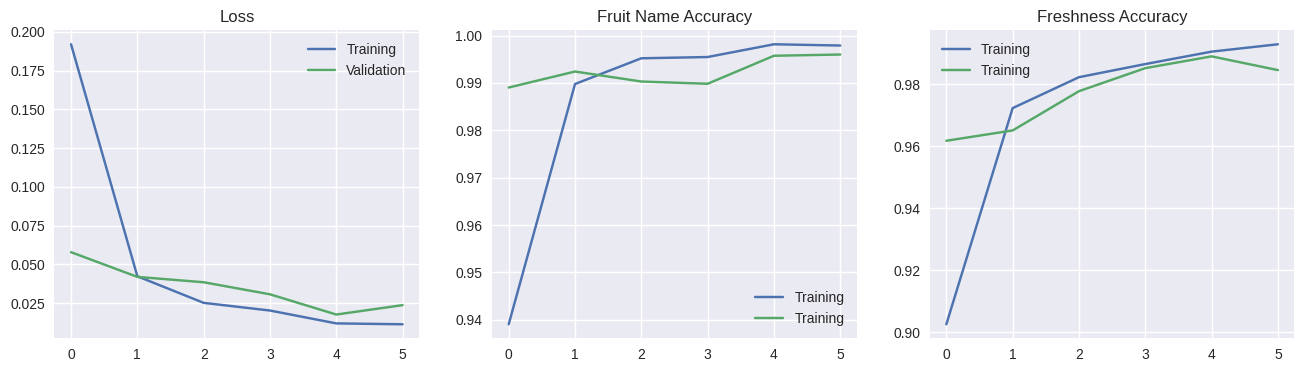

In [172]:
plt.figure(figsize = (16, 4))

plt.subplot(1,3,1)
plt.title('Loss')
plt.plot(model_vgg16.history['train_loss'], label = 'Training')
plt.plot(model_vgg16.history['val_loss'], label = 'Validation')
plt.legend()

plt.subplot(1,3,2)
plt.title('Fruit Name Accuracy')
plt.plot(model_vgg16.history['train_acc_fruit'], label = 'Training')
plt.plot(model_vgg16.history['val_acc_fruit'], label = 'Training')
plt.legend()

plt.subplot(1,3,3)
plt.title('Freshness Accuracy')
plt.plot(model_vgg16.history['train_acc_fresh'], label = 'Training')
plt.plot(model_vgg16.history['val_acc_fresh'], label = 'Training')
plt.legend()


# Model Predictions

In [173]:
preds1, preds2, fruit, fresh = [], [], [], []

with torch.no_grad():
    for x, y1, y2 in tqdm(test_loader):
        pred = model_vgg16(x.to(device))
        
        pred1 = torch.argmax(pred[0], axis = 1).detach().cpu().numpy()
        pred2 = torch.argmax(pred[1], axis = 1).detach().cpu().numpy()
        preds1.extend(pred1)
        preds2.extend(pred2)
        fruit.extend(y1)
        fresh.extend(y2)
        
        
len(fruit), len(fresh), len(preds1), len(preds2)

100%|██████████| 106/106 [01:04<00:00,  1.64it/s]


(6738, 6738, 6738, 6738)

Text(0.5, 1.0, 'Confusion Matrix for Fruit Names')

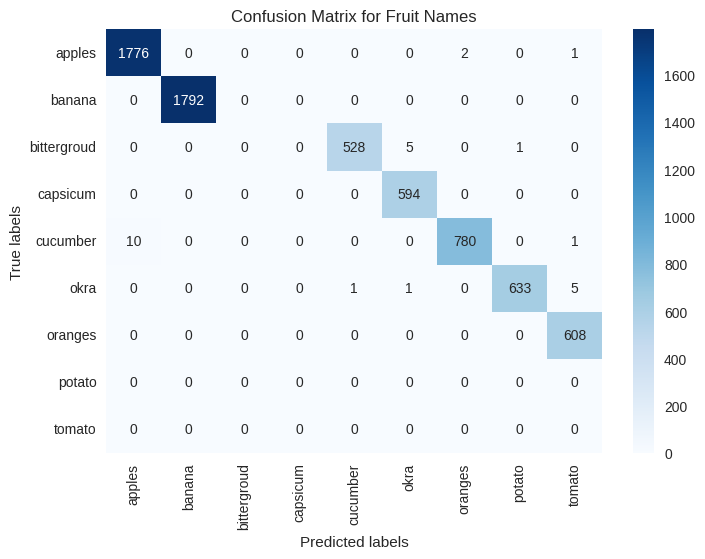

In [174]:
from sklearn.metrics import confusion_matrix

class_names = le_train.inverse_transform(np.arange(0, 9))

cm = confusion_matrix(fruit, preds1)
sea.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, xticklabels = class_names, yticklabels = class_names)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Fruit Names')

Text(0.5, 1.0, 'Confusion Matrix for Freshness')

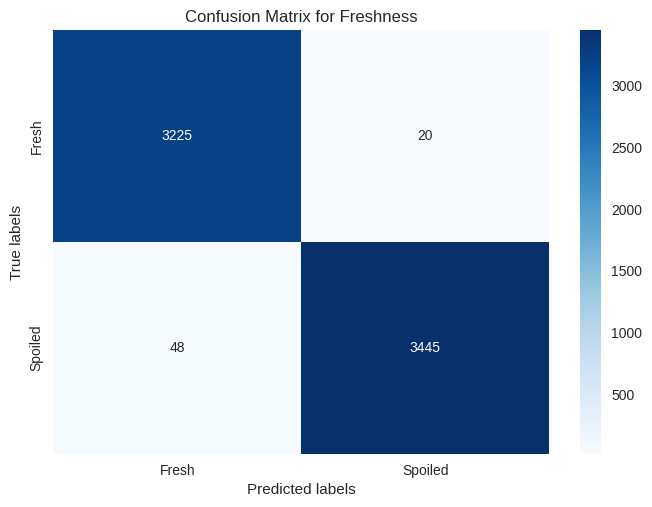

In [175]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(fresh, preds2)
sea.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, xticklabels = ['Fresh', 'Spoiled'], yticklabels = ['Fresh', 'Spoiled'])

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Freshness')

In [176]:
from sklearn.metrics import classification_report

print(classification_report(fruit, preds1, target_names = class_names))
print(classification_report(fresh, preds2, target_names = ['Fresh', 'Spoiled']))

              precision    recall  f1-score   support

      apples       0.99      1.00      1.00      1779
      banana       1.00      1.00      1.00      1792
 bittergroud       0.00      0.00      0.00       534
    capsicum       0.00      0.00      0.00       594
    cucumber       0.00      0.00      0.00       791
        okra       0.00      0.00      0.00       640
     oranges       0.00      0.00      0.00       608
      potato       0.00      0.00      0.00         0
      tomato       0.00      0.00      0.00         0

    accuracy                           0.53      6738
   macro avg       0.22      0.22      0.22      6738
weighted avg       0.53      0.53      0.53      6738

              precision    recall  f1-score   support

       Fresh       0.99      0.99      0.99      3245
     Spoiled       0.99      0.99      0.99      3493

    accuracy                           0.99      6738
   macro avg       0.99      0.99      0.99      6738
weighted avg       0.99

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.